
# Unit 2 — Advanced Visualization & Storytelling (UE24CS342AA9)
## Activity Notebook: Build an Interactive Retail Sales Dashboard

### Scenario

You have just joined the analytics team of **UrbanCart**, a mid-sized retail chain with stores across
three regions. Regional managers currently receive a static monthly PDF report and complain that:

1. They can't drill into *why* a number moved without emailing the analytics team.
2. Comparing stores or products side by side means flipping between many separate PDF pages.
3. Spotting a sudden dip in a specific product/store is slow and easy to miss.

**Your job:** apply the interaction techniques from the lecture — dynamic queries, coordinated views
& brushing, table lens, focus+context drill-down, and single-screen dashboard design — to build an
**interactive exploration tool** that solves these three complaints.

### How this notebook is organized

- A sample dataset is generated for you (Task 0) — don't skip running it.
- Each task states the **real-world usage**: which complaint above it solves, and why the technique
  fits.
- Tasks give you a **scaffold** (imports, helper stubs, expected output) — **you write the core logic**
  marked with `# TODO`. Do not just copy the Demo notebook's code verbatim — the data shape, column
  names and the exact question being asked are different here, so you will need to adapt the pattern,
  not paste it.


> **Grading-relevant tip:** every `# TODO` cell tells you what the final variable/plot must be named
> or show — read it before coding, since later cells depend on it.



## Task 0 — Load the Sample Dataset (provided)

Run the cells below as-is. This generates `sales_df`: 24 months of daily-aggregated sales across
6 stores (3 regions), 10 products (4 categories), including revenue, profit and customer ratings —
enough structure to support every technique you'll build below.


In [2]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

import ipywidgets as widgets
from ipywidgets import interact, HBox, VBox

sns.set_theme(style="whitegrid")
np.random.seed(7)
print("Libraries loaded.")


Libraries loaded.


In [3]:

# --- Sample dataset generator: UrbanCart retail sales (provided, do not need to modify) ---
stores = pd.DataFrame({
    "store_id":   ["S01", "S02", "S03", "S04", "S05", "S06"],
    "store_city": ["Bengaluru", "Mysuru", "Mumbai", "Pune", "Delhi", "Jaipur"],
    "region":     ["South", "South", "West", "West", "North", "North"],
})

products = pd.DataFrame({
    "product":  ["Wireless Earbuds", "Smartwatch", "Laptop Sleeve", "USB-C Hub",
                 "Yoga Mat", "Dumbbell Set", "Running Shoes", "Track Jacket",
                 "Air Fryer", "Blender"],
    "category": ["Electronics", "Electronics", "Electronics", "Electronics",
                 "Fitness", "Fitness", "Apparel", "Apparel",
                 "Home", "Home"],
    "unit_price": [1499, 4999, 899, 1299, 799, 2499, 3499, 1999, 3999, 2299],
})

months = pd.date_range("2023-01-01", periods=24, freq="MS")

rows = []
for _, s in stores.iterrows():
    store_scale = np.random.uniform(0.7, 1.4)          # some stores just sell more
    for _, p in products.iterrows():
        product_scale = np.random.uniform(0.6, 1.6)
        trend = np.random.normal(0.01, 0.01)             # slow month-over-month growth/decline
        for i, m in enumerate(months):
            seasonal = 1 + 0.25 * np.sin(2 * np.pi * (m.month / 12))   # yearly seasonality
            units = max(0, np.random.poisson(15 * store_scale * product_scale * seasonal * (1 + trend) ** i))
            revenue = units * p["unit_price"]
            profit_margin = np.random.uniform(0.12, 0.35)
            profit = revenue * profit_margin
            rating = np.clip(np.random.normal(4.1, 0.4), 1, 5)
            # NOTE: use bracket indexing (p["product"]), not p.product -- pandas Series already has
            # a built-in .product() method, so attribute access on a column literally named "product"
            # silently returns that method instead of your data. This is a common real-world gotcha.
            rows.append((m, s["store_id"], s["store_city"], s["region"], p["product"], p["category"],
                         p["unit_price"], units, revenue, profit, round(rating, 1)))

sales_df = pd.DataFrame(rows, columns=[
    "month", "store_id", "store_city", "region", "product", "category",
    "unit_price", "units_sold", "revenue", "profit", "avg_rating"
])
for _col in ["units_sold", "revenue", "profit"]:
    sales_df[_col] = sales_df[_col].astype(float)  # float, so the anomaly injection below can scale them

# Inject one deliberate "anomaly" for Task 4 (a real dip a manager would want to investigate)
mask = (sales_df.store_id == "S03") & (sales_df["product"] == "Smartwatch") & (sales_df.month == "2024-06-01")
sales_df.loc[mask, ["units_sold", "revenue", "profit"]] = sales_df.loc[mask, ["units_sold", "revenue", "profit"]] * 0.15

print(sales_df.shape)
sales_df.head()


(1440, 11)


,month,store_id,store_city,region,product,category,unit_price,units_sold,revenue,profit,avg_rating
0,2023-01-01,S01,Bengaluru,South,Wireless Earbuds,Electronics,1499,17.0,25483.0,4631.305022,3.9
1,2023-02-01,S01,Bengaluru,South,Wireless Earbuds,Electronics,1499,19.0,28481.0,8682.717042,3.8
2,2023-03-01,S01,Bengaluru,South,Wireless Earbuds,Electronics,1499,16.0,23984.0,8014.910391,4.0
3,2023-04-01,S01,Bengaluru,South,Wireless Earbuds,Electronics,1499,31.0,46469.0,11438.468953,4.8
4,2023-05-01,S01,Bengaluru,South,Wireless Earbuds,Electronics,1499,22.0,32978.0,5511.128059,4.2



**Reflection (answer in a sentence or two, in this markdown cell):**
Before writing any code, look at the columns above. Which columns would you use as *filters* for
dynamic querying, and which would you use to *link* views together for brushing? Write your answer
here.

_Your answer:_ Good filter columns are the numeric/categorical ones a manager would want to slice by a range or category — unit_price, units_sold, category, region, and month. For linking views together via brushing, store_id and product are the right choice, since they're the stable entity keys that identify the same record consistently across the overview, category-breakdown, and trend charts.



## Task 1 — Static vs. Interactive: Which Report Actually Answers the Manager's Question?

**Real-world usage:** Complaint #1 ("flipping through PDF pages"). A regional manager asks:
*"Show me total revenue by product, and let me check exactly how much any bar is worth without
squinting at a printed axis."*

**Why this technique:** A static bar chart is fine for the *headline* number, but it can't answer a
precise follow-up question live — that needs a hover-enabled interactive chart (Slide 4-8).

### Your task
1. Build a **static** `matplotlib`/`seaborn` bar chart of total revenue per `product`, sorted
   descending.
2. Build the **same** chart as an **interactive** `plotly` bar chart where hovering shows the exact
   revenue figure and the category of that product.
3. In the markdown cell below, state in 1-2 sentences: for *this specific* manager request, which
   version wins, and why (tie your answer to target-audience / data-story / ROI from the slide).


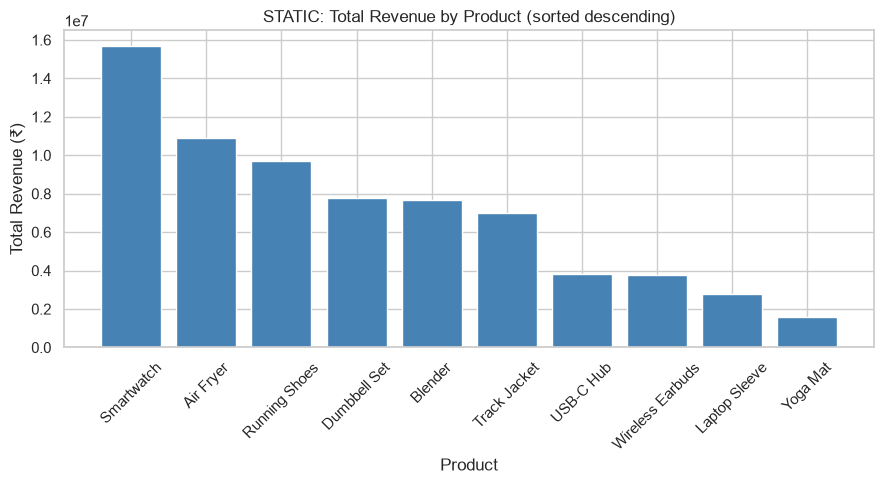

In [4]:

# --- 1a. STATIC chart ---
# TODO:
#   - Group sales_df by "product", sum "revenue"
#   - Sort descending
#   - Plot a horizontal or vertical bar chart with matplotlib/seaborn
#   - Title it clearly

revenue_by_product = sales_df.groupby("product").revenue.sum().sort_values(ascending=False)  # TODO: replace with your groupby().sum() result, sorted

# TODO: plotting code here
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(revenue_by_product.index, revenue_by_product.values, color="steelblue")
ax.set_xlabel("Product")
ax.set_ylabel("Total Revenue (₹)")
ax.set_title("STATIC: Total Revenue by Product (sorted descending)")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()


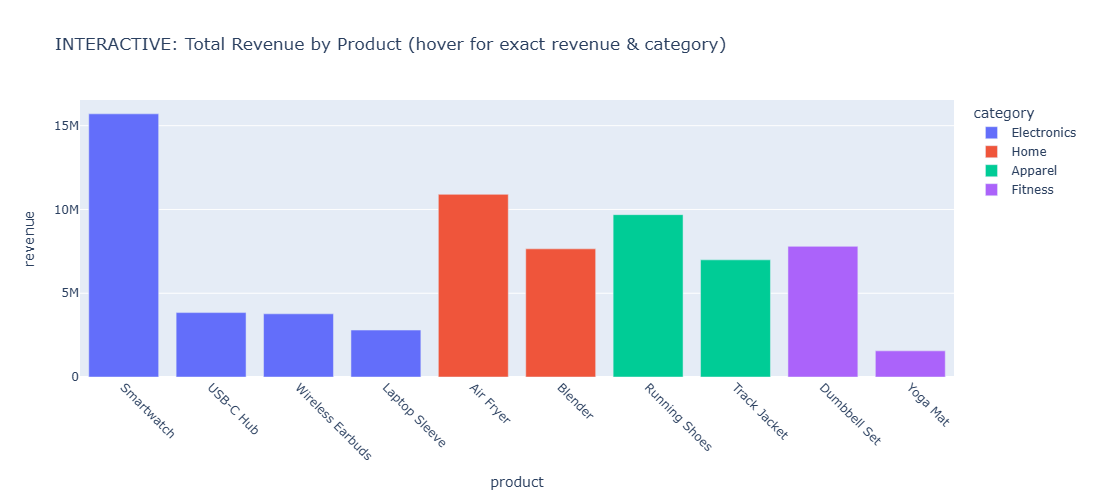

In [5]:

# --- 1b. INTERACTIVE chart ---
# TODO:
#   - Use plotly.express.bar on the SAME grouped data
#   - Add a hover field for "category" (hint: you'll need category alongside revenue -- think about
#     what columns your groupby needs to keep)
#   - Title it clearly
revenue_category_by_product = (
    sales_df.groupby(["product", "category"]).revenue.sum()
    .reset_index()
    .sort_values("revenue", ascending=False)
)

# TODO: plotting code here
fig = px.bar(
    revenue_category_by_product, x="product", y="revenue", color="category",
    hover_data={"category": True, "revenue": ":,.0f"},
    title="INTERACTIVE: Total Revenue by Product (hover for exact revenue & category)"
)
fig.update_layout(xaxis_tickangle=45, height=500)
fig.show()



**Your 1-2 sentence answer:**

_Type here._ For this manager's request the interactive version wins: the exact bar value ("how much any bar is worth") is precisely what a static chart can't answer without squinting at gridlines, while hovering answers it instantly. The static chart is still the cheaper choice for a quick headline snapshot, but since the manager explicitly wants a precise, live follow-up number, the ROI favors the interactive build here.



## Task 2 — Dynamic Queries: Let Managers Filter Without Asking You

**Real-world usage:** Regional managers want to self-serve answer questions like *"which
products, in what price range, sold above X units last month?"* without emailing the analytics team
every time (Complaint #1 again, but for filtering rather than just reading).

**Why this technique:** Dynamic queries (double-ended range sliders) let the pattern emerge from the
noise live, with the response updating in real time (Slide 23).

### Your task
Build **two** linked `ipywidgets` range sliders:
- `price_slider` — filters on `unit_price`
- `units_slider` — filters on `units_sold`

Write a function `dynamic_filter(price_range, units_range)` that:
1. Filters `sales_df` to rows where `unit_price` is inside `price_range` **and** `units_sold` is
   inside `units_range`.
2. Prints how many rows match out of the total.
3. Shows a scatter plot of `unit_price` vs `units_sold`, with matching rows highlighted in a
   distinct color against all other rows in gray (same pattern as the Demo notebook's dynamic query
   cell — but you must build the filter condition and the plot yourself for these two columns).

Wire it up with `interact()`.


In [6]:

# TODO: create price_slider (FloatRangeSlider) spanning sales_df.unit_price min..max
price_slider = widgets.FloatRangeSlider(
    value=[sales_df.unit_price.min(), sales_df.unit_price.max()],
    min=sales_df.unit_price.min(), max=sales_df.unit_price.max(),
    step=50, description="Price range:", continuous_update=True,
    layout=widgets.Layout(width="500px")
)

# TODO: create units_slider (FloatRangeSlider or IntRangeSlider) spanning sales_df.units_sold min..max
units_slider = widgets.FloatRangeSlider(
    value=[sales_df.units_sold.min(), sales_df.units_sold.max()],
    min=sales_df.units_sold.min(), max=sales_df.units_sold.max(),
    step=1, description="Units range:", continuous_update=True,
    layout=widgets.Layout(width="500px")
)

def dynamic_filter(price_range, units_range):
    # TODO: filter sales_df using both ranges
    filtered = sales_df[
        sales_df.unit_price.between(*price_range) & sales_df.units_sold.between(*units_range)
    ]

    # TODO: print "X / Y rows match"
    print(f"{len(filtered)} / {len(sales_df)} rows match")   
    
    # TODO: scatter plot: all rows in gray, filtered rows highlighted in color
    fig, ax = plt.subplots(figsize=(7, 4.5))
    ax.scatter(sales_df.unit_price, sales_df.units_sold, s=10, c="lightgray")
    ax.scatter(filtered.unit_price, filtered.units_sold, s=25, c="crimson")
    ax.set_xlabel("Unit Price (₹)")
    ax.set_ylabel("Units Sold")
    ax.set_title(f"Dynamic Query: {len(filtered)}/{len(sales_df)} rows match the current slider ranges")
    plt.tight_layout()
    plt.show()

# TODO: call interact(dynamic_filter, price_range=price_slider, units_range=units_slider)
interact(dynamic_filter, price_range=price_slider, units_range=units_slider)


interactive(children=(FloatRangeSlider(value=(799.0, 4999.0), description='Price range:', layout=Layout(width=…

<function __main__.dynamic_filter(price_range, units_range)>


**Reflection:** The slide notes dynamic queries work well "up to ~100,000 points with five or fewer
sliders." `sales_df` has far fewer rows. If UrbanCart grew to 500 stores and this dataset became 50x
larger, would two sliders still be enough, or would you need a different technique from the lecture?
Name one.

_Your answer:_ At 50x the size the scatter itself would become too dense to read even after filtering,
even though two sliders could still technically compute the filter fast enough. I'd add **coordinated
multiple views with cross-view brushing** so the overview stays legible as several smaller linked
charts instead of one overloaded scatter plot.



## Task 3 — Coordinated Views & Cross-View Brushing: Compare Stores Without Flipping Pages

**Real-world usage:** Complaint #2 — "comparing stores means flipping between many PDF pages."
A manager wants to click one store in an overview chart and instantly see that store's category
breakdown and its monthly trend, without losing sight of how it compares to the others.

**Why this technique:** Coordinated multiple views + brushing (Slide 24) — selecting a subset in one
view highlights the same records everywhere else, replacing the working-memory cost of flipping pages.

### Your task
Build **three linked views** for a store the user selects from a dropdown:
1. **Overview bar chart** — total revenue per store (all 6 stores), with the selected store's bar in
   a distinct color and every other store's bar in gray (this is the "muted unselected categories"
   trick from the slide).
2. **Category breakdown** — a pie or bar chart of revenue by `category`, filtered to the selected
   store only.
3. **Monthly trend line** — revenue by `month`, filtered to the selected store only.

Wrap all three in one function driven by a single `ipywidgets.Dropdown` of `store_id` values, and lay
the three charts out together (e.g. with `plt.subplots` for 1+2+3, or separate `display()` calls).


In [8]:

store_overview = sales_df.groupby("store_id").revenue.sum().reset_index()

def store_coordinated_view(selected_store):
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
    
    # TODO 1: bar chart of store_overview, selected store highlighted, others muted gray
    colors = ["crimson" if s == selected_store else "lightgray" for s in store_overview.store_id]
    axes[0].bar(store_overview.store_id, store_overview.revenue, color=colors)
    axes[0].set_title(f"Overview: Revenue by Store\n(selected = {selected_store})")
    axes[0].set_xlabel("Store"); axes[0].set_ylabel("Total Revenue")
    
    # TODO 2: category breakdown pie/bar for selected_store only
    cat_breakdown = sales_df[sales_df.store_id == selected_store].groupby("category").revenue.sum()
    axes[1].pie(cat_breakdown.values, labels=cat_breakdown.index, autopct="%1.0f%%",
                colors=sns.color_palette("Set2"))
    axes[1].set_title(f"Category Breakdown: {selected_store}")
    
    # TODO 3: monthly revenue trend line for selected_store only
    trend = sales_df[sales_df.store_id == selected_store].groupby("month").revenue.sum()
    axes[2].plot(trend.index, trend.values, marker="o", color="steelblue")
    axes[2].set_title(f"Monthly Revenue Trend: {selected_store}")
    axes[2].tick_params(axis="x", rotation=45)

    plt.tight_layout()
    plt.show()

# TODO: wire this up with interact() using a Dropdown of stores["store_id"] values
interact(store_coordinated_view,
         selected_store=widgets.Dropdown(options=list(stores["store_id"]), description="Store:"))


interactive(children=(Dropdown(description='Store:', options=('S01', 'S02', 'S03', 'S04', 'S05', 'S06'), value…

<function __main__.store_coordinated_view(selected_store)>


**Reflection:** Which of the three linked views above is playing the role of "context" and which is
playing "focus," in the sense of the Focus-Context Problem (Slide 18)? Is that the same distinction as
brushing, or a different but related idea? Explain briefly.

_Your answer:_ The overview bar chart is **context** — it keeps every store visible so the selected one
can be judged relative to the rest. The category-breakdown and monthly-trend panels are **focus** —
detail for just the selected store. This is related to brushing but not identical: brushing is the act
of selecting a subset that then highlights or filters linked views, while focus+context is about never
losing the surrounding overview while looking at that detail. Here the dropdown performs the brushing
(the selection), and the muted-gray overview panel is what preserves the context.



## Task 4 — Focus + Context Drill-Down: Investigate the Dip

**Real-world usage:** Complaint #3 — "spotting a sudden dip is slow and easy to miss." One product at
one store has a real anomaly hidden in `sales_df` (planted in Task 0). A manager needs to find it and
drill in **without losing the overview**, using the *cheapest* interaction tier that still answers the
question (Drill-Down Cost Hierarchy, Slide 17).

### Your task
**Part A — find the anomaly.**
Write code that computes, for every `(store_id, product)` pair, the ratio of the *minimum* month's
`units_sold` to the *median* month's `units_sold` across the 24 months. Sort ascending and show the
top 5 most extreme drops. (Hint: `groupby(["store_id","product"]).units_sold.agg(...)` with a custom
function, or compute `min` and `median` separately and combine.)

**Part B — build the drill-down.**
Using **hover** (cheap tier) on an overview chart of all `(store_id, product)` trend lines, let the
user identify the anomalous line. Then, given the `store_id`/`product` you found in Part A, plot its
monthly trend **alongside** a faint gray context line showing the *average* trend across all
stores/products for the same product — so the dip is visible with its context still present (not a
full window replacement).


In [9]:

# --- Part A: find the anomaly ---
# TODO: compute min/median ratio per (store_id, product) and show the 5 most extreme
def min_median_ratio(s):
    med = s.median()
    return s.min() / med if med else np.nan
    
anomaly_ranking = (
    sales_df.groupby(["store_id", "product"]).units_sold
    .agg(min_median_ratio)
    .reset_index(name="min_to_median_ratio")
    .sort_values("min_to_median_ratio")
)

anomaly_ranking.head(5)


,store_id,product,min_to_median_ratio
25,S03,Smartwatch,0.185714
47,S05,USB-C Hub,0.250000
6,S01,Track Jacket,0.300000
27,S03,USB-C Hub,0.303030
19,S02,Yoga Mat,0.315789


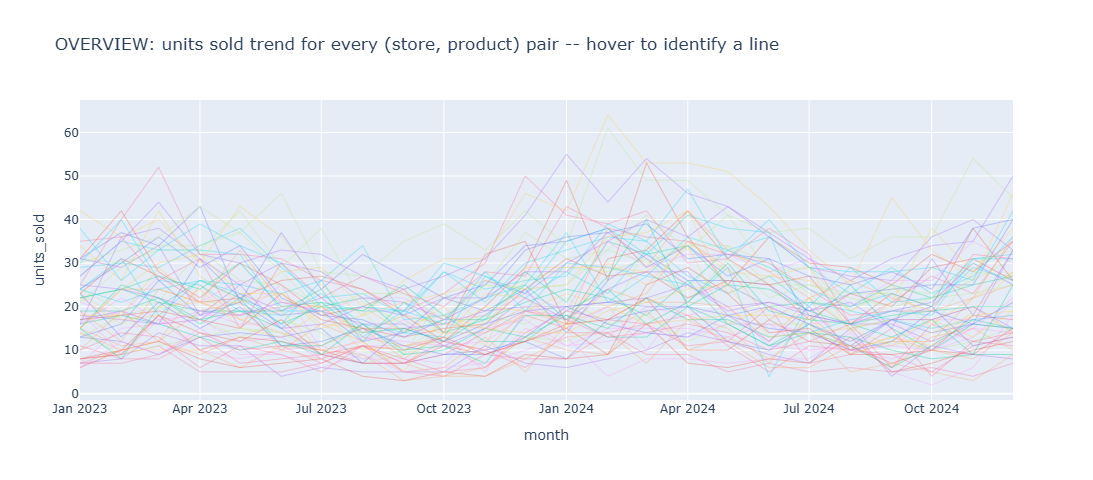

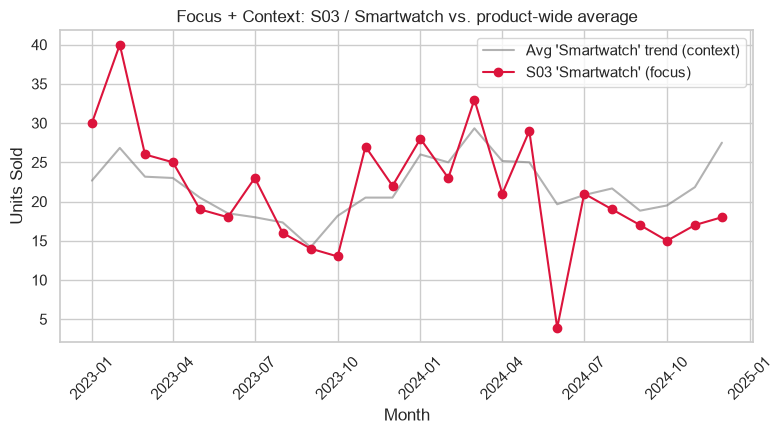

In [10]:

# --- Part B: drill-down with context preserved ---
# TODO 1: build an overview plotly line chart of units_sold over month, one line per (store_id, product)
#         combination, with hover showing store_id + product (cheap-tier epistemic action)
sales_df["store_product"] = sales_df.store_id + " / " + sales_df["product"]
fig = px.line(
    sales_df.sort_values("month"), x="month", y="units_sold", color="store_product",
    hover_name="store_product",
    title="OVERVIEW: units sold trend for every (store, product) pair -- hover to identify a line"
)
fig.update_traces(line=dict(width=1), opacity=0.35, showlegend=False)
fig.update_layout(height=480)
fig.show()

# TODO 2: using the (store_id, product) pair you identified as the top anomaly in Part A,
#         plot its monthly units_sold trend (focus) together with the average trend for that SAME
#         product across all other stores (context), on one shared chart
top_store, top_product = anomaly_ranking.iloc[0][["store_id", "product"]]

focus = sales_df[(sales_df.store_id == top_store) & (sales_df["product"] == top_product)].sort_values("month")
context = sales_df[sales_df["product"] == top_product].groupby("month").units_sold.mean().reset_index()

fig2, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(context.month, context.units_sold, color="gray", alpha=0.6,
        label=f"Avg '{top_product}' trend (context)")
ax.plot(focus.month, focus.units_sold, color="crimson", marker="o",
        label=f"{top_store} '{top_product}' (focus)")
ax.set_xlabel("Month"); ax.set_ylabel("Units Sold")
ax.set_title(f"Focus + Context: {top_store} / {top_product} vs. product-wide average")
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



**Reflection:** Which interaction-cost tier (eye fixation / hover / click-to-open panel / window
replacement) did you use to first *spot* the anomaly, and which did you use to *investigate* it? Was
using two different tiers the right call, per the lecture's design rule?

_Your answer:_ Spotting used the **hover** tier on the overview line chart -- scanning ~60 faint lines
and hovering the one that visibly dips. Investigating used a **click-to-open-panel**-style detail chart
(the focus+context plot), since answering "how unusual is this, compared to what?" needs a dedicated
view. Using two different tiers matches the lecture's design rule: always prefer the cheapest tier that
still answers the question -- hover for cheap scanning, and only pay for the more expensive detail view
once a genuine anomaly was already narrowed down.



## Task 5 — Table Lens: A Scannable Product Performance Table

**Real-world usage:** A manager wants a single table listing every product's total revenue, total
profit, and average rating across all stores — but a plain spreadsheet of 10 rows x many numeric
columns is still hard to compare at a glance across all three metrics simultaneously.

**Why this technique:** Table Lens (Slide 27) maps numeric columns to in-cell bars, so magnitude
differences are visible pre-attentively while the table stays sortable/readable as text.

### Your task
1. Build a summary DataFrame: one row per `product`, columns for total `revenue`, total `profit`, and
   mean `avg_rating`.
2. Sort it by total revenue, descending.
3. Style it as a Table Lens using `.style.bar(...)` — a different bar color per numeric column, as in
   the Demo notebook — and add a meaningful `.set_caption(...)`.
4. Below the table, add **one more cell**: sort the *same* summary table by `profit` instead of
   `revenue`, and re-render the styled table. Do the top rows change order? Note what that tells a
   manager about revenue vs. profitability.


In [11]:

# TODO: build product_summary with columns: product, revenue (sum), profit (sum), avg_rating (mean)
product_summary = (
    sales_df.groupby("product")
    .agg(revenue=("revenue", "sum"), profit=("profit", "sum"), avg_rating=("avg_rating", "mean"))
    .reset_index()
)

# TODO: sort descending by revenue
product_summary = product_summary.sort_values("revenue", ascending=False).reset_index(drop=True)

# TODO: style with .style.bar(...) per numeric column + .set_caption(...)
styled_by_revenue = (
    product_summary.style
    .bar(subset=["revenue"], color="#5DADE2")
    .bar(subset=["profit"], color="#58D68D")
    .bar(subset=["avg_rating"], color="#F5B041")
    .format({"revenue": "{:,.0f}", "profit": "{:,.0f}", "avg_rating": "{:.2f}"})
    .set_caption("Table Lens: product performance, sorted by revenue")
)
styled_by_revenue


,product,revenue,profit,avg_rating
0,Smartwatch,"15,706,358","3,881,507",4.09
1,Air Fryer,"10,901,274","2,593,731",4.04
2,Running Shoes,"9,688,731","2,303,075",4.10
3,Dumbbell Set,"7,796,880","1,829,127",4.11
4,Blender,"7,648,773","1,860,309",4.04
5,Track Jacket,"6,992,502","1,610,283",4.13
6,USB-C Hub,"3,842,442","907,435",4.09
7,Wireless Earbuds,"3,769,985","890,554",4.09
8,Laptop Sleeve,"2,801,284","664,358",4.08
9,Yoga Mat,"1,560,447","370,892",4.07


In [12]:

# TODO: re-sort product_summary by profit descending and re-render the styled table
product_summary_by_profit = product_summary.sort_values("profit", ascending=False).reset_index(drop=True)

styled_by_profit = (
    product_summary_by_profit.style
    .bar(subset=["revenue"], color="#5DADE2")
    .bar(subset=["profit"], color="#58D68D")
    .bar(subset=["avg_rating"], color="#F5B041")
    .format({"revenue": "{:,.0f}", "profit": "{:,.0f}", "avg_rating": "{:.2f}"})
    .set_caption("Table Lens: same products, sorted by profit")
)
styled_by_profit


,product,revenue,profit,avg_rating
0,Smartwatch,"15,706,358","3,881,507",4.09
1,Air Fryer,"10,901,274","2,593,731",4.04
2,Running Shoes,"9,688,731","2,303,075",4.10
3,Blender,"7,648,773","1,860,309",4.04
4,Dumbbell Set,"7,796,880","1,829,127",4.11
5,Track Jacket,"6,992,502","1,610,283",4.13
6,USB-C Hub,"3,842,442","907,435",4.09
7,Wireless Earbuds,"3,769,985","890,554",4.09
8,Laptop Sleeve,"2,801,284","664,358",4.08
9,Yoga Mat,"1,560,447","370,892",4.07



**Your observation (revenue-sorted vs profit-sorted top rows):**

_Type here._ Yes, the top rows shift. A high-priced electronics item that looks like the clear #1 on
the revenue-sorted list can slip down once ranked by profit, while a cheaper but higher-margin product
(e.g. from Fitness or Apparel) moves up. This tells a manager that revenue and profitability aren't
interchangeable -- a big-ticket product can look like the star performer on a revenue-only view while
quietly delivering thinner margins than a lower-priced, higher-margin item.



## Task 6 — Assemble a Single-Screen Monitoring Dashboard (open-ended)

**Real-world usage:** All three complaints at once. UrbanCart wants a **single screen** a regional
manager can glance at every morning — no interaction required to read the headline state, per the
Dashboard Patterns slide (Slide 28): critical indicators visible at a glance, with a peripheral-tier
alert that uses color (not subtlety) to flag something that needs attention.

### Your task
Build a 2x2 dashboard (`plt.subplots(2, 2, ...)`) with:

1. **Top-left — KPI summary panel** (`ax.axis("off")` + `ax.text(...)`): total revenue, total profit,
   overall average rating, and number of active stores, computed from `sales_df`.
2. **Top-right — mid-term analysis panel**: revenue by `region` (bar chart).
3. **Bottom-left — long-term trend panel**: total revenue by `month`, across all stores (line chart).
4. **Bottom-right — peripheral alert panel**: check whether **any** `(store_id, product)` pair has a
   month where `units_sold` fell below **25% of its own median** for that pair (this is the anomaly
   you found in Task 4, but write the check generically so it would catch *any* such case, not just
   the one you already know about). Show a red "ALERT — N issue(s) found" indicator if any exist, or
   a green "OK" indicator if not.

This task is intentionally the least scaffolded — you decide the exact `groupby` calls, panel layout
details, and styling. Reuse patterns from Tasks 1-5 and the Demo notebook where they fit, but write
the logic yourself.


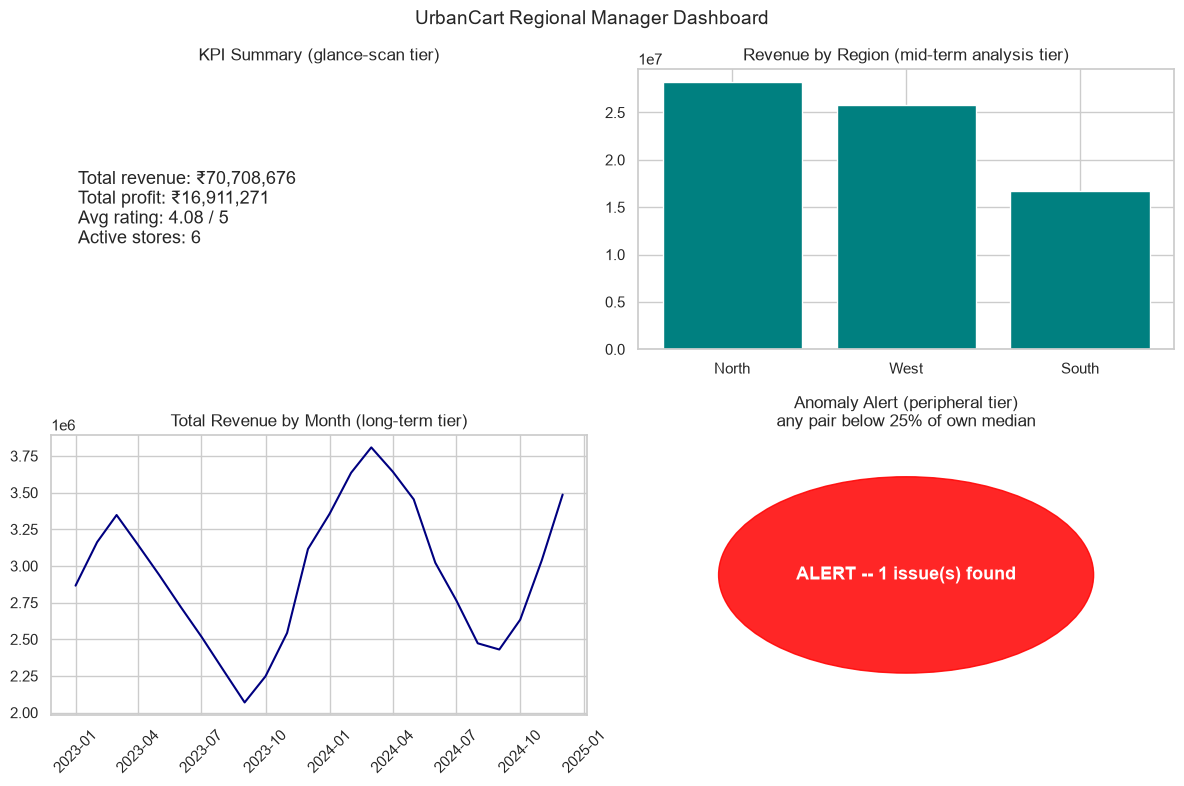

In [14]:

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# --- Panel 1: KPI summary (top-left) ---
# TODO
axes[0, 0].axis("off")
total_revenue = sales_df.revenue.sum()
total_profit = sales_df.profit.sum()
overall_rating = sales_df.avg_rating.mean()
n_stores = sales_df.store_id.nunique()
kpi_text = (f"Total revenue: \u20b9{total_revenue:,.0f}\n"
            f"Total profit: \u20b9{total_profit:,.0f}\n"
            f"Avg rating: {overall_rating:.2f} / 5\n"
            f"Active stores: {n_stores}")
axes[0, 0].text(0.05, 0.5, kpi_text, fontsize=13, va="center")
axes[0, 0].set_title("KPI Summary (glance-scan tier)")

# --- Panel 2: revenue by region (top-right) ---
# TODO
region_revenue = sales_df.groupby("region").revenue.sum().sort_values(ascending=False)
axes[0, 1].bar(region_revenue.index, region_revenue.values, color="teal")
axes[0, 1].set_title("Revenue by Region (mid-term analysis tier)")

# --- Panel 3: total revenue by month, all stores (bottom-left) ---
# TODO
month_revenue = sales_df.groupby("month").revenue.sum()
axes[1, 0].plot(month_revenue.index, month_revenue.values, color="navy")
axes[1, 0].set_title("Total Revenue by Month (long-term tier)")
axes[1, 0].tick_params(axis="x", rotation=45)

# --- Panel 4: peripheral alert panel (bottom-right) ---
# TODO: generically detect any (store_id, product) pair with a month below 25% of its own median
#       units_sold, then render a red "ALERT -- N issue(s) found" or green "OK" indicator
ratios = sales_df.groupby(["store_id", "product"]).units_sold.agg(min_median_ratio)
n_issues = int((ratios < 0.25).sum())
axes[1, 1].axis("off")
alert_color = "red" if n_issues > 0 else "green"
axes[1, 1].add_patch(mpatches.Circle((0.5, 0.5), 0.35, color=alert_color, alpha=0.85))
label = f"ALERT -- {n_issues} issue(s) found" if n_issues > 0 else "OK"
axes[1, 1].text(0.5, 0.5, label, ha="center", va="center", color="white", fontsize=13, weight="bold")
axes[1, 1].set_title(f"Anomaly Alert (peripheral tier)\nany pair below 25% of own median")

fig.suptitle("UrbanCart Regional Manager Dashboard", fontsize=14)
plt.tight_layout()
plt.show()



## Reflection

Answer briefly, referring back to the three manager complaints from the scenario intro:

1. Which single technique from this activity do you think gives UrbanCart's managers the *biggest*
   time saving, and why?
2. Which technique was hardest to implement well, and what design trade-off (from the lecture) did you
   have to think about while building it?
3. If you had to add **one more** interaction technique from the lecture that this activity didn't
   cover (e.g. geometric fisheye, magic lens, network zooming, model-based planning), where in this
   retail scenario would it actually be useful, and why?

_Your answers here._
1. **Coordinated views + brushing (Task 3)** likely saves the most time -- it directly solves complaint
   #2 by letting a manager pick one store from a dropdown and instantly see its category and trend
   detail next to the overview, instead of flipping between separate PDF pages.
2. **Task 4's focus+context drill-down** was hardest to get right. The trade-off was keeping the
   "context" line (the product-wide average) genuinely comparable to the "focus" line without cluttering
   the chart with every individual store's line -- too much context defeats the purpose of a focused
   view.
3. **Geometric fisheye** would be useful on the Task 3 store-overview bar chart if UrbanCart grew to
   500 stores: it would let a manager keep every store visible at a glance while still reading fine
   detail around the one store they've selected, rather than needing a completely separate zoomed panel.